# UADY · Modelos de Ingreso — Notebook consolidado
**IA Enterprise · Sistema Synapse**

Análisis de los resultados públicos de admisión a licenciatura de la UADY
(2022–2026, fuente: ingreso.uady.mx). Un solo cuaderno con:

1. **EDA** — exploración de los datos.
2. **Regresión** — pronostica `POSICION` (lugar en el ranking).
3. **Clasificación** — pronostica `ESTATUS` (Admitido / No admitido).
4. **Modelos de producción** — pipelines de scikit-learn puros para la app.

> Requiere el entorno de entrenamiento (Python 3.11 + `requirements-train.txt`).
> Selecciona el kernel del venv `.venv` antes de ejecutar.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
RUTA_DATA = "data/Salida_UADY_ML_26.csv"  # ejecutar desde la raíz del repo

## 1. Carga y normalización de datos

El CSV viene en UTF-8 con BOM. Normalizamos los nombres de columna a nombres
ASCII estables (la columna de pensamiento matemático trae tilde en el origen).

In [2]:
df = pd.read_csv(RUTA_DATA, encoding="utf-8-sig")
df = df.rename(columns={c: "indice_Pensamiento_Matematico" for c in df.columns
                        if c.lower().startswith("indice_pensamiento")})
df = df.rename(columns={c: "indice_Ceneval" for c in df.columns
                        if c.lower().startswith("indice_ceneval")})
if "POSICIÓN" in df.columns:
    df = df.rename(columns={"POSICIÓN": "POSICION"})
print(df.shape)
df.head()

(67094, 7)


,FOLIO CENEVAL,ESTATUS,Abv.1,Ciclo,POSICION,indice_Ceneval,indice_Pensamiento_Matematico
0,624077488,Admitido,IQI,2026,69,983,1040
1,624077490,No admitido,REH,2026,301,952,920
2,624077517,Admitido,CPU,2026,442,1035,880
3,624077529,No admitido,MCI,2026,3804,941,840
4,624077538,Admitido,CPU,2026,49,1178,1240


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67094 entries, 0 to 67093
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   FOLIO CENEVAL                  67094 non-null  int64 
 1   ESTATUS                        67094 non-null  object
 2   Abv.1                          67094 non-null  object
 3   Ciclo                          67094 non-null  int64 
 4   POSICION                       67094 non-null  int64 
 5   indice_Ceneval                 67094 non-null  int64 
 6   indice_Pensamiento_Matematico  67094 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 3.6+ MB


In [4]:
df.isnull().sum().sort_values(ascending=False)

FOLIO CENEVAL                    0
ESTATUS                          0
Abv.1                            0
Ciclo                            0
POSICION                         0
indice_Ceneval                   0
indice_Pensamiento_Matematico    0
dtype: int64

## 2. Análisis exploratorio (EDA)

### 2.1 Balance de clases (ESTATUS)
El objetivo de clasificación está desbalanceado (~2:1), por eso en el modelo
usamos `fix_imbalance=True`.

ESTATUS
No admitido    44365
Admitido       22729
Name: count, dtype: int64


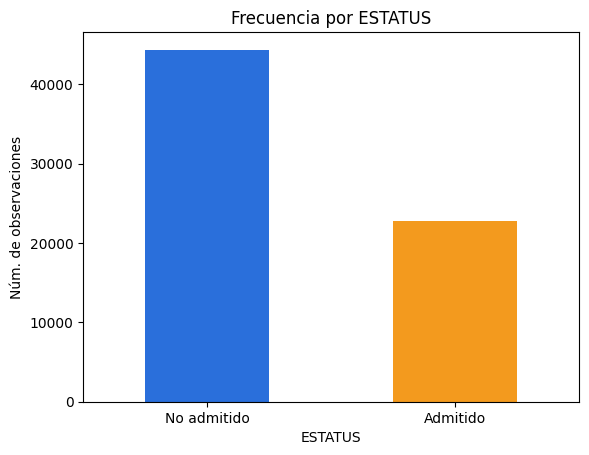

In [5]:
conteo = df["ESTATUS"].value_counts()
print(conteo)
conteo.plot(kind="bar", rot=0, color=["#2A6FDB", "#F39A1E"])
plt.title("Frecuencia por ESTATUS"); plt.ylabel("Núm. de observaciones"); plt.show()

In [6]:
df.describe()

,FOLIO CENEVAL,Ciclo,POSICION,indice_Ceneval,indice_Pensamiento_Matematico
count,6.709400e+04,67094.000000,67094.000000,67094.000000,67094.000000
mean,6.049482e+08,2024.022983,654.234119,1065.151057,1079.932632
std,1.112293e+08,1.438708,884.413677,79.705202,123.859295
min,4.271861e+08,2022.000000,1.000000,700.000000,700.000000
25%,5.264932e+08,2023.000000,91.000000,1004.000000,980.000000
50%,6.241792e+08,2024.000000,284.000000,1061.000000,1080.000000
75%,7.162654e+08,2025.000000,698.000000,1122.000000,1180.000000
max,7.225462e+08,2026.000000,3898.000000,1291.000000,1300.000000


### 2.2 Matriz de correlación
Relación entre los índices y la posición.

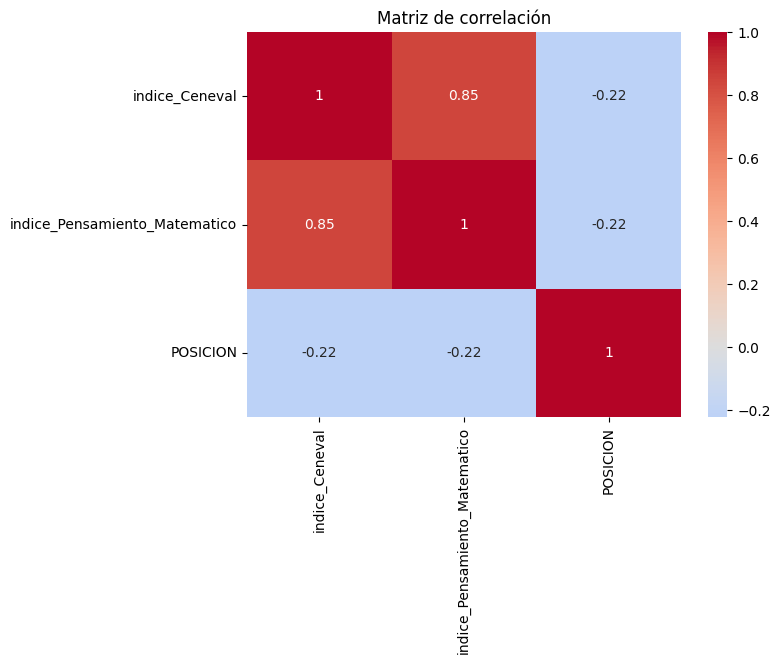

In [7]:
num = ["indice_Ceneval", "indice_Pensamiento_Matematico", "POSICION"]
plt.figure(figsize=(7, 5))
sns.heatmap(df[num].corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación"); plt.show()

### 2.3 Distribución por ciclo
Cuántos registros hay por año (incluye 2026, el ciclo más reciente).

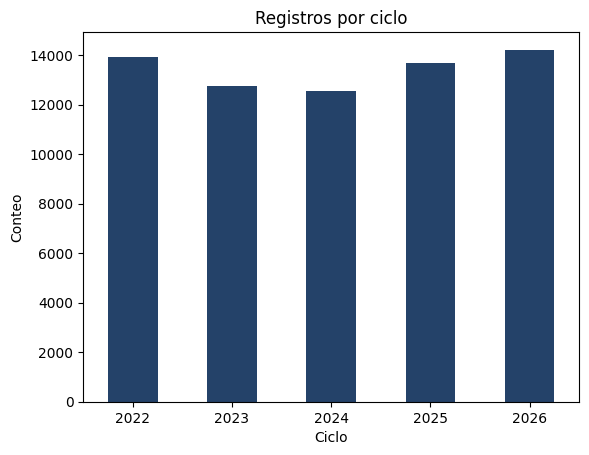

In [8]:
df["Ciclo"].value_counts().sort_index().plot(kind="bar", rot=0, color="#244269")
plt.title("Registros por ciclo"); plt.ylabel("Conteo"); plt.show()

## 3. Modelo de REGRESIÓN — `POSICION`

Configuración (igual a la histórica): se ignoran `FOLIO CENEVAL`, `ESTATUS` y
`Ciclo`; `Abv.1` es categórica (one-hot). Split 75/25 reproducible.

In [9]:
from pycaret.regression import (
    setup as r_setup, compare_models as r_compare, create_model as r_create,
    predict_model as r_predict, finalize_model as r_finalize, pull as r_pull,
    save_model as r_save, plot_model as r_plot,
)
ignore_r = ["FOLIO CENEVAL", "ESTATUS", "Ciclo"]
datos = df.sample(frac=0.75, random_state=0).reset_index(drop=True)
r_setup(data=datos, target="POSICION", session_id=123, ignore_features=ignore_r,
        categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)

### 3.1 Comparación de algoritmos

In [10]:
r_best = r_compare()
r_pull()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,94.6431,32134.3872,179.2047,0.9585,0.4210,0.4484,1.6240
xgboost,Extreme Gradient Boosting,95.2651,32787.0295,181.0200,0.9577,0.3794,0.3665,0.1600
lightgbm,Light Gradient Boosting Machine,98.7534,34178.7272,184.8260,0.9559,0.4091,0.4218,0.1550
rf,Random Forest Regressor,94.9918,35214.9748,187.6022,0.9546,0.3395,0.2884,0.8910
et,Extra Trees Regressor,96.2853,36041.0673,189.7868,0.9535,0.3558,0.2930,0.9680
dt,Decision Tree Regressor,96.5981,36321.0385,190.5316,0.9531,0.3743,0.3012,0.0520
gbr,Gradient Boosting Regressor,122.1166,39778.4263,199.4013,0.9487,0.6746,0.9351,0.3780
ada,AdaBoost Regressor,188.4775,61338.3236,247.6465,0.9208,1.0316,2.5270,0.4950
ridge,Ridge Regression,284.1628,154556.4323,393.0938,0.8006,1.3633,8.5914,0.0430
lr,Linear Regression,284.1926,154558.8363,393.0969,0.8006,1.3635,8.6015,0.5280


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,94.6431,3.213439e+04,179.2047,0.9585,0.4210,0.4484,1.624
xgboost,Extreme Gradient Boosting,95.2651,3.278703e+04,181.0200,0.9577,0.3794,0.3665,0.160
lightgbm,Light Gradient Boosting Machine,98.7534,3.417873e+04,184.8260,0.9559,0.4091,0.4218,0.155
rf,Random Forest Regressor,94.9918,3.521497e+04,187.6022,0.9546,0.3395,0.2884,0.891
et,Extra Trees Regressor,96.2853,3.604107e+04,189.7868,0.9535,0.3558,0.2930,0.968
dt,Decision Tree Regressor,96.5981,3.632104e+04,190.5316,0.9531,0.3743,0.3012,0.052
gbr,Gradient Boosting Regressor,122.1166,3.977843e+04,199.4013,0.9487,0.6746,0.9351,0.378
ada,AdaBoost Regressor,188.4775,6.133832e+04,247.6465,0.9208,1.0316,2.5270,0.495
ridge,Ridge Regression,284.1628,1.545564e+05,393.0938,0.8006,1.3633,8.5914,0.043
lr,Linear Regression,284.1926,1.545588e+05,393.0969,0.8006,1.3635,8.6015,0.528


### 3.2 Modelo LightGBM y diagnóstico

In [11]:
r_modelo = r_create("lightgbm")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,99.6637,34842.1746,186.6606,0.9560,0.3997,0.3968
1,99.1272,34749.0475,186.4110,0.9554,0.4032,0.4287
2,99.3992,33260.9203,182.3758,0.9568,0.4105,0.4390
3,96.0395,33242.4126,182.3250,0.9558,0.4134,0.4271
4,94.9041,31802.4562,178.3324,0.9610,0.4043,0.3926
5,97.4731,34062.7211,184.5609,0.9558,0.4188,0.4630
6,102.8114,36922.1591,192.1514,0.9508,0.4019,0.4021
7,97.3896,32783.7832,181.0629,0.9576,0.4036,0.4142
8,97.6056,33361.1269,182.6503,0.9538,0.4172,0.4283


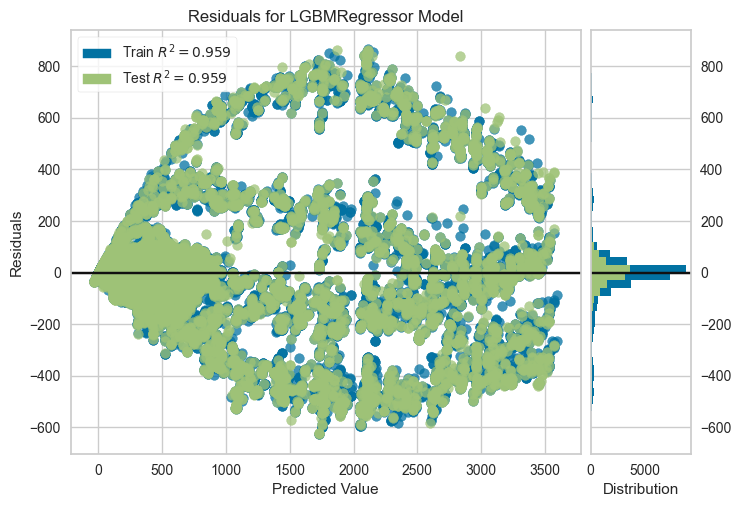

In [12]:
r_plot(r_modelo, plot="residuals")

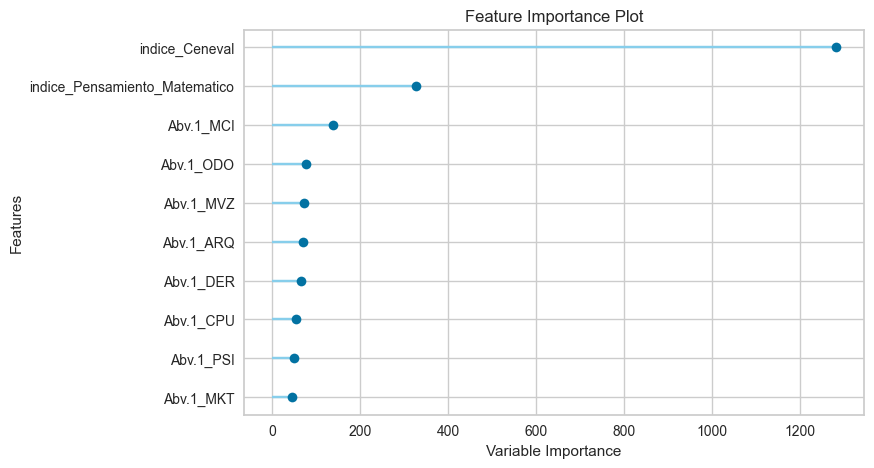

In [13]:
r_plot(r_modelo, plot="feature")

### 3.3 Validación temporal (entrenar ≤2025 → predecir 2026)
Escenario realista: ¿qué tan bien pronostica el ciclo siguiente nunca visto?

In [14]:
train_t = df[df["Ciclo"] <= 2025].reset_index(drop=True)
test_t  = df[df["Ciclo"] == 2026].reset_index(drop=True)
r_setup(data=train_t, target="POSICION", session_id=123, ignore_features=ignore_r,
        categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)
r_mod_t = r_create("lightgbm")
r_predict(r_mod_t, data=test_t)
r_pull()

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,96.5649,32406.4075,180.0178,0.9572,0.3907,0.4061
1,97.1468,32981.5230,181.6082,0.9555,0.3889,0.3883
2,99.5034,34558.8792,185.9002,0.9539,0.3683,0.3472
3,98.7880,34179.4695,184.8769,0.9536,0.4005,0.4091
4,96.8572,32288.3532,179.6896,0.9558,0.4114,0.4113
5,98.1875,33504.9742,183.0436,0.9525,0.3700,0.3661
6,98.3268,33694.5888,183.5609,0.9560,0.3880,0.3705
7,94.8725,31674.2756,177.9727,0.9545,0.3979,0.3995
8,99.3117,33681.5946,183.5255,0.9526,0.3840,0.3661


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,152.8758,64541.0509,254.0493,0.9324,0.4021,0.3597


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,152.8758,64541.0509,254.0493,0.9324,0.4021,0.3597


### 3.4 Modelo final (todos los datos) y guardado

In [15]:
r_setup(data=df, target="POSICION", session_id=123, ignore_features=ignore_r,
        categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)
r_final = r_finalize(r_create("lightgbm"))
r_save(r_final, "models/modelo_regresion")
print("Guardado models/modelo_regresion.pkl")

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,100.3233,35425.4564,188.2165,0.9553,0.4100,0.4230
1,97.9606,33265.3039,182.3878,0.9578,0.4268,0.4622
2,96.6408,32783.2064,181.0613,0.9572,0.4149,0.4380
3,97.7724,32999.3279,181.6572,0.9576,0.4087,0.4029
4,98.2599,33943.8439,184.2386,0.9574,0.3928,0.3891
5,99.1889,33162.9311,182.1069,0.9568,0.4209,0.4637
6,97.0318,32168.9175,179.3570,0.9582,0.4092,0.4192
7,98.0863,33684.8517,183.5343,0.9568,0.4080,0.4113
8,92.7272,30825.5688,175.5721,0.9592,0.3935,0.4007


Transformation Pipeline and Model Successfully Saved
Guardado models/modelo_regresion.pkl


## 4. Modelo de CLASIFICACIÓN — `ESTATUS`

Se ignoran `Ciclo`, `FOLIO CENEVAL` y `POSICION`; `fix_imbalance=True` para el
desbalance; se ordena por `Recall` (priorizar detectar a los admitidos).

In [16]:
from pycaret.classification import (
    setup as c_setup, compare_models as c_compare, create_model as c_create,
    predict_model as c_predict, finalize_model as c_finalize, pull as c_pull,
    save_model as c_save, plot_model as c_plot,
)
ignore_c = ["Ciclo", "FOLIO CENEVAL", "POSICION"]
c_setup(data=datos, target="ESTATUS", session_id=123, ignore_features=ignore_c,
        fix_imbalance=True, categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)

### 4.1 Comparación de algoritmos (orden por Recall)

In [17]:
c_best = c_compare(sort="Recall")
c_pull()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9479,0.9916,0.9479,0.9479,0.9479,0.8839,0.8840,7.6530
lightgbm,Light Gradient Boosting Machine,0.9471,0.9915,0.9471,0.9470,0.9470,0.8819,0.8820,0.3550
xgboost,Extreme Gradient Boosting,0.9469,0.9912,0.9469,0.9468,0.9468,0.8814,0.8815,0.3230
rf,Random Forest Classifier,0.9395,0.9871,0.9395,0.9395,0.9395,0.8652,0.8653,0.5490
et,Extra Trees Classifier,0.9373,0.9662,0.9373,0.9376,0.9374,0.8609,0.8610,0.6890
dt,Decision Tree Classifier,0.9368,0.9502,0.9368,0.9372,0.9370,0.8600,0.8601,0.2070
lr,Logistic Regression,0.9343,0.9852,0.9343,0.9364,0.9348,0.8561,0.8573,1.4280
gbc,Gradient Boosting Classifier,0.9307,0.9823,0.9307,0.9305,0.9306,0.8452,0.8453,0.6900
ada,Ada Boost Classifier,0.9223,0.9793,0.9223,0.9228,0.9225,0.8278,0.8280,0.4090
lda,Linear Discriminant Analysis,0.9149,0.9823,0.9149,0.9244,0.9163,0.8182,0.8249,0.2550


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
catboost,CatBoost Classifier,0.9479,0.9916,0.9479,0.9479,0.9479,0.8839,0.8840,7.653
lightgbm,Light Gradient Boosting Machine,0.9471,0.9915,0.9471,0.9470,0.9470,0.8819,0.8820,0.355
xgboost,Extreme Gradient Boosting,0.9469,0.9912,0.9469,0.9468,0.9468,0.8814,0.8815,0.323
rf,Random Forest Classifier,0.9395,0.9871,0.9395,0.9395,0.9395,0.8652,0.8653,0.549
et,Extra Trees Classifier,0.9373,0.9662,0.9373,0.9376,0.9374,0.8609,0.8610,0.689
dt,Decision Tree Classifier,0.9368,0.9502,0.9368,0.9372,0.9370,0.8600,0.8601,0.207
lr,Logistic Regression,0.9343,0.9852,0.9343,0.9364,0.9348,0.8561,0.8573,1.428
gbc,Gradient Boosting Classifier,0.9307,0.9823,0.9307,0.9305,0.9306,0.8452,0.8453,0.690
ada,Ada Boost Classifier,0.9223,0.9793,0.9223,0.9228,0.9225,0.8278,0.8280,0.409
lda,Linear Discriminant Analysis,0.9149,0.9823,0.9149,0.9244,0.9163,0.8182,0.8249,0.255


### 4.2 Modelo LightGBM y diagnóstico

In [18]:
c_modelo = c_create("lightgbm")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9444,0.9912,0.9444,0.9442,0.9443,0.8758,0.8758
1,0.9483,0.9917,0.9483,0.9483,0.9483,0.8849,0.8849
2,0.9486,0.9926,0.9486,0.9486,0.9486,0.8856,0.8856
3,0.9412,0.9903,0.9412,0.9410,0.9411,0.8684,0.8686
4,0.9452,0.9906,0.9452,0.9450,0.9450,0.8773,0.8774
5,0.9469,0.9911,0.9469,0.9470,0.9469,0.8819,0.8819
6,0.9495,0.9917,0.9495,0.9496,0.9495,0.8877,0.8877
7,0.9512,0.9922,0.9512,0.9510,0.9511,0.8909,0.8910
8,0.9495,0.9926,0.9495,0.9493,0.9493,0.8870,0.8871


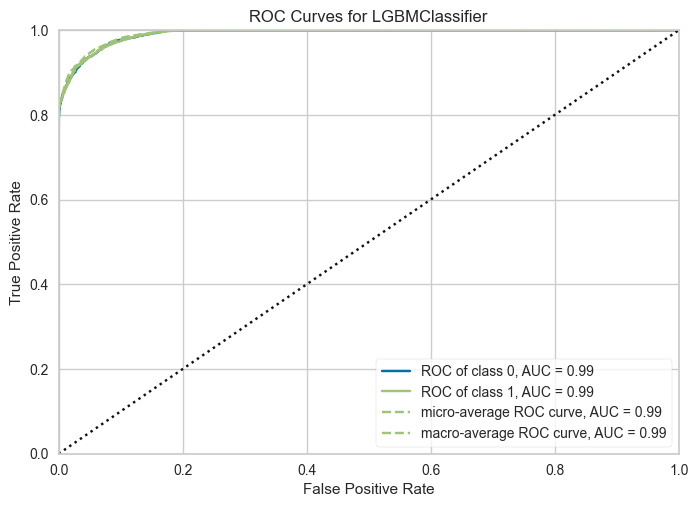

In [19]:
c_plot(c_modelo, plot="auc")

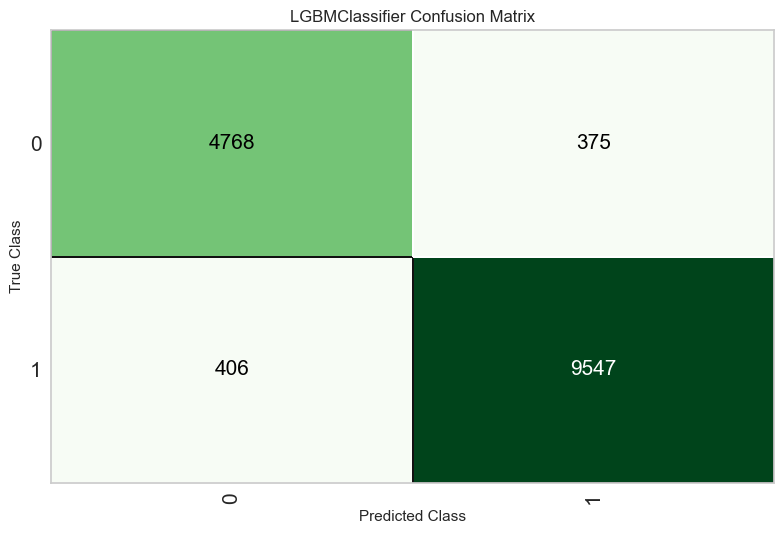

In [20]:
c_plot(c_modelo, plot="confusion_matrix")

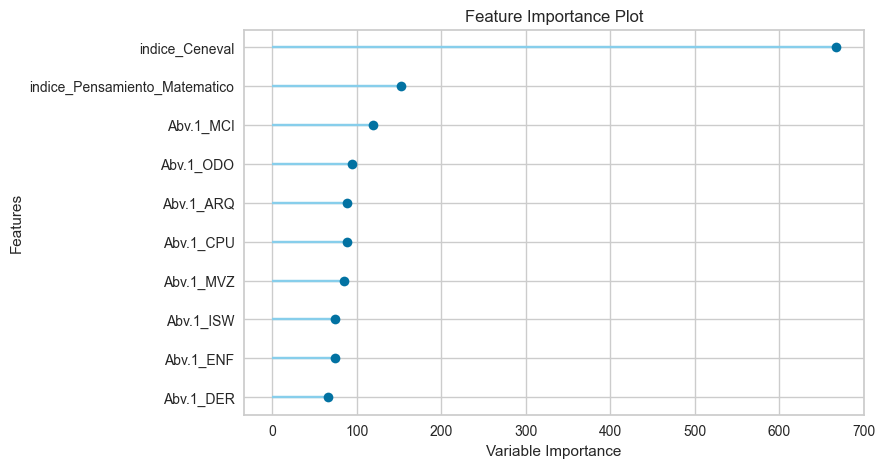

In [21]:
c_plot(c_modelo, plot="feature")

### 4.3 Validación temporal (entrenar ≤2025 → predecir 2026)

In [22]:
c_setup(data=train_t, target="ESTATUS", session_id=123, ignore_features=ignore_c,
        fix_imbalance=True, categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)
c_mod_t = c_create("lightgbm")
c_predict(c_mod_t, data=test_t)
c_pull()

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9484,0.9922,0.9484,0.9483,0.9483,0.8827,0.8827
1,0.9368,0.9882,0.9368,0.9367,0.9368,0.8565,0.8565
2,0.9465,0.9908,0.9465,0.9466,0.9465,0.8788,0.8789
3,0.9503,0.9915,0.9503,0.9502,0.9502,0.8870,0.8870
4,0.9392,0.9897,0.9392,0.9394,0.9393,0.8625,0.8626
5,0.9422,0.9897,0.9422,0.9421,0.9421,0.8686,0.8686
6,0.9392,0.9900,0.9392,0.9394,0.9393,0.8624,0.8624
7,0.9473,0.9923,0.9473,0.9475,0.9474,0.8809,0.8810
8,0.9430,0.9910,0.9430,0.9430,0.9430,0.8706,0.8706


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9390,0.9890,0.9390,0.9393,0.9391,0.8708,0.8709


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.939,0.989,0.939,0.9393,0.9391,0.8708,0.8709


### 4.4 Modelo final (todos los datos) y guardado

In [23]:
c_setup(data=df, target="ESTATUS", session_id=123, ignore_features=ignore_c,
        fix_imbalance=True, categorical_features=["Abv.1"], max_encoding_ohe=49, verbose=False)
c_final = c_finalize(c_create("lightgbm"))
c_save(c_final, "models/modelo_clasificacion")
print("Guardado models/modelo_clasificacion.pkl")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9457,0.9908,0.9457,0.9456,0.9456,0.8785,0.8786
1,0.9466,0.9918,0.9466,0.9464,0.9464,0.8801,0.8802
2,0.9481,0.9915,0.9481,0.9479,0.9479,0.8833,0.8835
3,0.9461,0.9912,0.9461,0.9461,0.9461,0.8797,0.8797
4,0.9455,0.9910,0.9455,0.9456,0.9455,0.8784,0.8785
5,0.9478,0.9923,0.9478,0.9480,0.9479,0.8838,0.8838
6,0.9517,0.9919,0.9517,0.9515,0.9516,0.8917,0.8918
7,0.9453,0.9908,0.9453,0.9451,0.9451,0.8771,0.8773
8,0.9476,0.9919,0.9476,0.9475,0.9475,0.8827,0.8827


Transformation Pipeline and Model Successfully Saved
Guardado models/modelo_clasificacion.pkl


## 5. Modelos de PRODUCCIÓN (scikit-learn puro)

Los `.pkl` de PyCaret requieren PyCaret para cargarse. Para que la app de
Streamlit sea **ligera**, reconstruimos pipelines equivalentes solo con
scikit-learn + lightgbm.

In [24]:
import pickle
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

NUM = ["indice_Ceneval", "indice_Pensamiento_Matematico"]; CAT = ["Abv.1"]
def preprocesador():
    return ColumnTransformer([
        ("num", SimpleImputer(strategy="mean"), NUM),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore"))]), CAT),
    ])

clf_prod = Pipeline([("prep", preprocesador()),
                     ("model", LGBMClassifier(random_state=123, class_weight="balanced", n_jobs=-1))])
clf_prod.fit(df[NUM + CAT], df["ESTATUS"])
pickle.dump(clf_prod, open("models/clf_prod.pkl", "wb"))

reg_prod = Pipeline([("prep", preprocesador()),
                     ("model", LGBMRegressor(random_state=123, n_jobs=-1))])
reg_prod.fit(df[NUM + CAT], df["POSICION"])
pickle.dump(reg_prod, open("models/reg_prod.pkl", "wb"))
print("Guardados models/clf_prod.pkl y models/reg_prod.pkl")

[LightGBM] [Info] Number of positive: 44365, number of negative: 22729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000118 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 67094, number of used features: 51
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000150 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 299
[LightGBM] [Info] Number of data points in the train set: 67094, number of used features: 51
[LightGBM] [Info] Start training from score 654.234119


Guardados models/clf_prod.pkl y models/reg_prod.pkl


### 5.1 Prueba rápida de inferencia

In [25]:
ejemplo = pd.DataFrame({"Abv.1": ["ODO"], "indice_Ceneval": [1030],
                       "indice_Pensamiento_Matematico": [1040]})
print("Estatus:", clf_prod.predict(ejemplo)[0],
      "| Score Admitido:", round(clf_prod.predict_proba(ejemplo)[0][list(clf_prod.classes_).index("Admitido")]*100, 2))
print("Posición estimada:", round(reg_prod.predict(ejemplo)[0]))

Estatus: No admitido | Score Admitido: 0.13
Posición estimada: 450


## 6. Conclusiones

- **Regresión (POSICION):** R² ≈ 0.95 en CV; en validación temporal 2026, R² ≈ 0.93
  con MAE ≈ 153 posiciones (el error real al pronosticar un ciclo nuevo es mayor
  que el de CV — esperado, depende de la competencia de cada año).
- **Clasificación (ESTATUS):** Accuracy ≈ 0.94 y AUC ≈ 0.99, estable en la
  validación temporal 2026.
- Los modelos de producción en scikit-learn puro replican las métricas sin
  depender de PyCaret, lo que permite un deploy ligero en Streamlit.